In [12]:
import torch
import torch.nn as nn
from torch.autograd import Variable
import matplotlib.pyplot as plt
import matplotlib.animation as animation
import numpy as np
import time
from collections import OrderedDict
from torch.autograd import Variable

a = -1  
b = 0   
c = 1   
k = 3   
num_epochs = 10000

pinn_initial_epochs = 3000  # 初始PINN训练轮数
pinn_adaptive_epochs = 2000  # 每次自适应采样后的PINN训练轮数
num_iterations = 2  # 迭代次数
mmpde_training_epochs = 2000  # MMPDE训练轮数

nu = 0.001
adam_lr = 0.001
lbfgs_lr = 0.5

In [13]:
def analytical_solution(t, x):
    u = x * torch.cos(5 * torch.pi * t) + torch.pow(x * t, 3)
    return u.reshape(-1, 1)

def U_t(x, t):
    return -5 * torch.pi * x * torch.sin(5 * torch.pi * t) + 3 * x**2 * t**2

def U_x(x, t):
    return torch.cos(5 * torch.pi * t) + 3 * t**3 * x**2

def U_tt(x, t):
    return -25 * torch.pi**2 * x * torch.cos(5 * torch.pi * t) + 6 * t * x**3

def U_xx(x, t):
    return 6 * x * t**3

def PDE_source(x, t):
    return U_tt(x, t) + a * U_xx(x, t) + b * analytical_solution(t, x) + c * torch.pow(analytical_solution(t, x), k)

def Energy_source(x, t):
    return U_t(x, t)**2 + a * U_x(x, t)**2 + b * analytical_solution(t, x)**2 + c/2 * analytical_solution(t, x)**4

In [14]:
class PINN(nn.Module):
    def __init__(self, input_size, hidden_size):
        super(PINN, self).__init__()
        self.linear1 = nn.Linear(input_size, hidden_size)
        self.linear2 = nn.Linear(hidden_size, hidden_size)
        self.linear3 = nn.Linear(hidden_size, hidden_size)
        self.linear4 = nn.Linear(hidden_size, hidden_size)
        self.output = nn.Linear(hidden_size, 1)  
        self.tanh = nn.Tanh()
        self.iter = 0

    def forward(self, x, t=None):
        if t is not None:
            inputs = torch.cat([t, x], dim=1)  
        else:
            inputs = x
            
        out = self.linear1(inputs)
        out = self.tanh(out)
        out = self.linear2(out)
        out = self.tanh(out)
        out = self.linear3(out)
        out = self.tanh(out)
        out = self.linear4(out)
        out = self.tanh(out)
        out = self.output(out)
        return out

In [15]:
class DNN(torch.nn.Module):
    def __init__(self, layers):
        super(DNN, self).__init__()

        # parameters
        self.depth = len(layers) - 1

        # set up layer order dict
        self.activation = torch.nn.Tanh

        layer_list = list()
        for i in range(self.depth - 1):
            layer_list.append(
                ('layer_%d' % i, torch.nn.Linear(layers[i], layers[i + 1]))
            )
            layer_list.append(('activation_%d' % i, self.activation()))

        layer_list.append(
            ('layer_%d' % (self.depth - 1), torch.nn.Linear(layers[-2], layers[-1]))
        )
        layerDict = OrderedDict(layer_list)

        # deploy layers
        self.layers = torch.nn.Sequential(layerDict)

    def forward(self, x):
        out = self.layers(x)
        return out

class sampling_MMPDE():
    def __init__(self, X_f, u_fun, layers, lb, ub, nu, AdamIter, LBFGSIter):
        self.lb = torch.tensor(lb).float()
        self.ub = torch.tensor(ub).float()

        self.t_f = torch.tensor(X_f[:, 0:1], requires_grad=True).float()
        self.x_f = torch.tensor(X_f[:, 1:2], requires_grad=True).float()
        self.fun = u_fun

        self.layers = layers
        self.nu = nu

        self.dnn = DNN(layers)

        self.optimizer_Adam = torch.optim.Adam(self.dnn.parameters(),
                                              lr=1e-3,
                                              betas=(0.9, 0.999),
                                              eps=1e-8)
        
        self.AdamIter = AdamIter

        self.optimizer_LBFGS = torch.optim.LBFGS(
            self.dnn.parameters(),
            lr=0.5,
            max_iter=LBFGSIter,
        )

        self.optimizer = None
        self.loss = None
        self.iter = 0
        self.start_time = None

    def detach(self, data):
        return data.detach().cpu().numpy()

    def monitor(self, u, t, x):

        u_t = torch.autograd.grad(
            u, t,
            grad_outputs=torch.ones_like(u),
            retain_graph=True,
            create_graph=True
        )[0]
        

        u_x = torch.autograd.grad(
            u, x,
            grad_outputs=torch.ones_like(u),
            retain_graph=True,
            create_graph=True
        )[0]
        
    
        w = u_t ** 2 + a * u_x ** 2 + b * u ** 2 + c/2 * u ** 4 - Energy_source(x, t)
        
        return w

    def net_sample(self, t, x):
        # 生成新的采样点
        xNew = self.dnn(torch.cat([t, x], dim=1))
        g0 = x - self.lb[1]
        g1 = x - self.ub[1]
        xNew = g0*g1*xNew + x
        return xNew

    def net_f(self, t, x):
        xNew = self.net_sample(t, x)

        xNew_t = torch.autograd.grad(
            xNew, t,
            grad_outputs=torch.ones_like(xNew),
            retain_graph=True,
            create_graph=True
        )[0]

        xNew_x = torch.autograd.grad(
            xNew, x,
            grad_outputs=torch.ones_like(xNew),
            retain_graph=True,
            create_graph=True
        )[0]
        
        xNew_xx = torch.autograd.grad(
            xNew_x, x,
            grad_outputs=torch.ones_like(xNew_x),
            retain_graph=True,
            create_graph=True
        )[0]


        u = self.fun(torch.cat([t, x], dim=1))
        
        G = self.monitor(u, t, x)

        G_t = torch.autograd.grad(
            G, t,
            grad_outputs=torch.ones_like(G),
            retain_graph=True,
            create_graph=True
        )[0]

        G_x = torch.autograd.grad(
            G, x,
            grad_outputs=torch.ones_like(G),
            retain_graph=True,
            create_graph=True
        )[0]


        E = G_x * xNew_x + G * xNew_xx
        f = xNew_t*self.nu*(G**2)*(xNew_x**2) + E

        return f

    def loss_func(self):
        f_pred = self.net_f(self.t_f, self.x_f)
        loss_f = torch.mean(f_pred ** 2)
        
        return loss_f

    def optimize_one_epoch(self):
        if self.start_time is None:
            self.start_time = time.time()

        self.optimizer.zero_grad()
        self.loss = self.loss_func()
        self.loss.backward()
        self.iter = self.iter + 1

        if self.iter % 100 == 0:
            loss = self.detach(self.loss)
            print(f"{self.optimizer_name} Iter {self.iter}, Loss: {loss:.6f}")
            elapsed = time.time() - self.start_time
            print(f'Time: {elapsed:.4f}s')
            self.start_time = time.time()

        return self.loss

    def train_Adam(self, optimizer, nIter):
        self.optimizer = optimizer
        self.optimizer_name = 'MMPDE_Adam'
        
        for it in range(nIter):
            self.optimize_one_epoch()
            self.optimizer.step()

    def train_LBFGS(self, optimizer):
        self.optimizer = optimizer
        self.optimizer_name = 'MMPDE_LBFGS'

        def closure():
            loss = self.optimize_one_epoch()
            return loss

        self.optimizer.step(closure)

    def train(self):
        print("开始MMPDE训练...")
        self.train_Adam(self.optimizer_Adam, self.AdamIter)
        print("MMPDE_Adam 完成!")
        self.train_LBFGS(self.optimizer_LBFGS)
        print('MMPDE_LBGFS 完成!')

        new_x = self.net_sample(self.t_f, self.x_f)
        new_sample = torch.cat([self.t_f, new_x], dim=1)
        return new_sample

In [16]:
# 新增cell - 创建基于模型的模拟函数
def create_simulation_function_from_model(model):
    """基于当前PINN模型创建模拟函数"""
    def simulation_function(xt):
        model.eval()
        # 确保输入张量需要梯度（MMPDE需要计算梯度）
        if not xt.requires_grad:
            xt = xt.requires_grad_(True)
        
        return model(xt)
    return simulation_function

def generate_uniform_collocation_points_kg(n_points=1000):
    """生成Klein-Gordon方程的均匀配点"""
    n_per_dim = int(np.sqrt(n_points))
    
    t_uniform = torch.linspace(0, 1, n_per_dim)
    x_uniform = torch.linspace(0, 1, n_per_dim)
    
    T_grid, X_grid = torch.meshgrid(t_uniform, x_uniform, indexing='ij')
    
    t_coll = T_grid.reshape(-1, 1)
    x_coll = X_grid.reshape(-1, 1)
    
    t_coll.requires_grad_(True)
    x_coll.requires_grad_(True)
    
    print(f"生成Klein-Gordon配点网格: {n_per_dim}×{n_per_dim} = {t_coll.shape[0]}个点")
    
    return t_coll, x_coll

def generate_initial_training_data_kg():
    """生成Klein-Gordon方程初始训练数据"""
    # 生成配点
    t_colloc, x_colloc = generate_uniform_collocation_points_kg(1000)
    x_colloc_combined = torch.cat([t_colloc, x_colloc], dim=1)
    
    # 边界条件
    N_bc = 100
    t_bc = torch.rand(N_bc, 1)
    x_bc_left = torch.zeros(N_bc//2, 1)  
    x_bc_right = torch.ones(N_bc//2, 1)
    x_bc = torch.cat([x_bc_left, x_bc_right], dim=0)
    t_bc_split = torch.split(t_bc, N_bc//2)
    x_bc_left_combined = torch.cat([t_bc_split[0], x_bc_left], dim=1)
    x_bc_right_combined = torch.cat([t_bc_split[1], x_bc_right], dim=1)
    x_bc_combined = torch.cat([x_bc_left_combined, x_bc_right_combined], dim=0)
    x_bc_combined.requires_grad_(True)
    
    # 初始条件
    N_ic = 100
    x_ic = torch.rand(N_ic, 1)
    t_ic = torch.zeros(N_ic, 1)
    x_ic_combined = torch.cat([t_ic, x_ic], dim=1)
    x_ic_combined.requires_grad_(True)
    
    return x_colloc_combined, x_bc_combined, x_ic_combined

def generate_initial_samples_kg(n_samples=1000):
    """生成Klein-Gordon方程MMPDE初始采样点"""
    n_per_dim = int(np.sqrt(n_samples))
    
    t_uniform = torch.linspace(0, 1, n_per_dim)
    x_uniform = torch.linspace(0, 1, n_per_dim)
    
    T_grid, X_grid = torch.meshgrid(t_uniform, x_uniform, indexing='ij')
    
    t_init = T_grid.reshape(-1, 1)
    x_init = X_grid.reshape(-1, 1)
    
    X_f_init = torch.cat([t_init, x_init], dim=1).numpy()
    
    print(f"生成Klein-Gordon MMPDE初始采样点: {n_per_dim}×{n_per_dim} = {X_f_init.shape[0]}个点")
    
    return X_f_init

In [17]:
# 新增cell - Klein-Gordon方程的组合优化器
class CombinedOptimizerKG:
    def __init__(self, model, x_colloc_combined, x_bc_combined, x_ic_combined):
        self.model = model
        self.x_colloc_combined = x_colloc_combined
        self.x_bc_combined = x_bc_combined
        self.x_ic_combined = x_ic_combined
        
        self.iter = 0
        
        # 设置默认训练轮数
        self.adam_iter = pinn_initial_epochs
        self.lbfgs_iter = pinn_initial_epochs // 4

        self.optimizer_adam = torch.optim.Adam(model.parameters(), lr=adam_lr)
        self.optimizer_lbfgs = torch.optim.LBFGS(
            model.parameters(), 
            lr=lbfgs_lr, 
            max_iter=20,
            max_eval=25,
            tolerance_grad=1e-9,
            tolerance_change=1e-12,
            history_size=50,
            line_search_fn="strong_wolfe"
        )
        
    def compute_loss(self):
        f = x_f_loss_fun(self.x_colloc_combined, self.model)
        loss_pde = torch.mean(f**2)
        loss_bc = boundary_loss(self.model, self.x_bc_combined)
        loss_ic = initial_condition_loss(self.model, self.x_ic_combined)
        total_loss = loss_pde + 10.0 * loss_bc + 10.0 * loss_ic
        return total_loss, loss_pde, loss_bc, loss_ic
    
    def lbfgs_closure(self):
        self.optimizer_lbfgs.zero_grad()
        total_loss, loss_pde, loss_bc, loss_ic = self.compute_loss()
        total_loss.backward()
        self.iter += 1
        
        if self.iter % 200 == 0:
            print(f'LBFGS Iter: {self.iter}, Loss: {total_loss.item():.6e}')
        
        return total_loss
    
    def train(self):
        print("Starting Adam training...")
        
        # Adam training phase
        scheduler = torch.optim.lr_scheduler.StepLR(self.optimizer_adam, step_size=500, gamma=0.8)
        
        for i in range(self.adam_iter):
            self.optimizer_adam.zero_grad()
            total_loss, loss_pde, loss_bc, loss_ic = self.compute_loss()
            total_loss.backward()
            
            # Gradient clipping
            torch.nn.utils.clip_grad_norm_(self.model.parameters(), max_norm=1.0)
            
            self.optimizer_adam.step()
            scheduler.step()
            self.iter += 1
            
            if i % 500 == 0:
                print(f'Adam Iter: {self.iter}, Loss: {total_loss.item():.6e}')
        
        print('Adam training completed!')
        
        # LBFGS training phase
        print("Starting LBFGS training...")
        for i in range(self.lbfgs_iter // 20):
            self.optimizer_lbfgs.step(self.lbfgs_closure)
        print('LBFGS training completed!')

In [18]:
def x_f_loss_fun(inputs, model):

    if not inputs.requires_grad:
        inputs = Variable(inputs, requires_grad=True)

    u = model(inputs)

    t = inputs[:, 0:1]
    x = inputs[:, 1:2]
    
    u_grad = torch.autograd.grad(u, inputs, grad_outputs=torch.ones_like(u), create_graph=True)[0]
    u_t = u_grad[:, 0:1]  
    u_x = u_grad[:, 1:2] 
    
    u_tt = torch.autograd.grad(u_t, inputs, grad_outputs=torch.ones_like(u_t), create_graph=True)[0][:, 0:1]

    u_xx = torch.autograd.grad(u_x, inputs, grad_outputs=torch.ones_like(u_x), create_graph=True)[0][:, 1:2]

    source = PDE_source(x, t)

    f = u_tt + a * u_xx + b * u + c * torch.pow(u, k) - source
    
    return f

In [19]:
def boundary_loss(model, x_bc):
    outputs = model(x_bc)
    
    t = x_bc[:, 0:1]
    x = x_bc[:, 1:2]

    u_bc_target = analytical_solution(t, x)
    
    return torch.mean((outputs - u_bc_target)**2)

def initial_condition_loss(model, x_ic):
    inputs = x_ic.clone().requires_grad_(True)
    outputs = model(inputs)

    x = inputs[:, 1:2]

    u_ic_target = x 
    disp_loss = torch.mean((outputs - u_ic_target)**2)

    u_t = torch.autograd.grad(
        outputs, inputs, 
        grad_outputs=torch.ones_like(outputs),
        create_graph=True
    )[0][:, 0:1]  
    
    vel_loss = torch.mean(u_t**2)  
    
    return disp_loss + vel_loss

In [20]:
# 新增cell - Klein-Gordon方程迭代训练函数
def iterative_training_with_adaptive_sampling_kg(
    initial_epochs,
    adaptive_epochs,
    num_iterations,
    mmpde_training_epochs
):
    print("=" * 80)
    print("开始迭代训练：PINN + MMPDE 自适应采样 (Klein-Gordon方程)")
    print("=" * 80)
    
    # ==================== 第一阶段：初始训练 ====================
    print(f"\n【第一阶段】使用均匀采样进行初始训练 ({initial_epochs} epochs)")
    
    # 创建初始模型
    model = PINN(2, 40)
    model.iter = 0
    
    # 初始训练数据
    x_colloc_combined, x_bc_combined, x_ic_combined = generate_initial_training_data_kg()
    
    # 创建初始采样点用于后续MMPDE
    current_sampling_points = generate_initial_samples_kg(n_samples=1000)
    
    # 创建组合优化器训练器
    combined_trainer = CombinedOptimizerKG(
        model, x_colloc_combined, x_bc_combined, x_ic_combined
    )
    
    # 初始训练
    print("开始初始训练...")
    combined_trainer.train()
    print(f"初始训练完成")
    
    # ==================== 迭代阶段：MMPDE + 继续训练 ====================
    for iteration in range(num_iterations):
        print(f"\n【第{iteration+2}阶段】迭代 {iteration+1}: MMPDE自适应采样 + 继续训练")
        
        # 基于当前模型进行MMPDE采样
        print("基于当前PINN模型进行MMPDE自适应采样...")
        
        # 使用当前模型创建模拟函数
        current_sim_func = create_simulation_function_from_model(model)
        
        # MMPDE参数
        mmpde_layers = [2, 20, 20, 20, 1]
        adam_iter = mmpde_training_epochs
        lbfgs_iter = 0  # Klein-Gordon使用更多Adam迭代
        
        # 创建MMPDE采样器
        mmpde_sampler = sampling_MMPDE(
            X_f=current_sampling_points,
            u_fun=current_sim_func,
            layers=mmpde_layers,
            lb=[0.0, 0.0],
            ub=[1.0, 1.0],
            nu=nu,
            AdamIter=adam_iter,
            LBFGSIter=lbfgs_iter
        )
        
        # 训练MMPDE并获取新采样点
        new_samples = mmpde_sampler.train()
        
        # 更新采样点用于下次迭代
        current_sampling_points = new_samples.detach().cpu().numpy()
        
        # 提取新的配点
        t_colloc_new = new_samples[:, 0:1].clone().detach().requires_grad_(True)
        x_colloc_new = new_samples[:, 1:2].clone().detach().requires_grad_(True)
        x_colloc_combined_new = torch.cat([t_colloc_new, x_colloc_new], dim=1)
        
        print(f"获得新的自适应采样点: {new_samples.shape[0]}个")
        
        # 使用新采样点创建新的训练器
        combined_trainer_new = CombinedOptimizerKG(
            model, x_colloc_combined_new, x_bc_combined, x_ic_combined
        )
        
        # 设置较小的训练轮数进行自适应训练
        combined_trainer_new.adam_iter = adaptive_epochs
        combined_trainer_new.lbfgs_iter = adaptive_epochs // 4
        
        # 继续训练
        print(f"使用新采样点继续训练...")
        combined_trainer_new.train()
        
        print(f"迭代 {iteration+1} 完成")
    
    print("\n" + "=" * 80)
    print("迭代训练完成！")
    print("=" * 80)
    
    return model, x_colloc_combined_new

开始迭代训练：PINN + MMPDE 自适应采样 (Klein-Gordon方程)

【第一阶段】使用均匀采样进行初始训练 (3000 epochs)
生成Klein-Gordon配点网格: 31×31 = 961个点
生成Klein-Gordon MMPDE初始采样点: 31×31 = 961个点
开始初始训练...
Starting Adam training...
Adam Iter: 1, Loss: 1.059660e+04
Adam Iter: 501, Loss: 1.444377e+03
Adam Iter: 1001, Loss: 7.533529e+01
Adam Iter: 1501, Loss: 7.266345e+00
Adam Iter: 2001, Loss: 3.424147e+00
Adam Iter: 2501, Loss: 2.574715e+00
Adam training completed!
Starting LBFGS training...
LBFGS Iter: 3200, Loss: 4.738166e-01
LBFGS Iter: 3400, Loss: 2.224751e-01
LBFGS Iter: 3600, Loss: 1.458841e-01
LBFGS training completed!
初始训练完成

【第2阶段】迭代 1: MMPDE自适应采样 + 继续训练
基于当前PINN模型进行MMPDE自适应采样...
开始MMPDE训练...
MMPDE_Adam Iter 100, Loss: 51.525234
Time: 1.2140s
MMPDE_Adam Iter 200, Loss: 37.894783
Time: 1.2398s
MMPDE_Adam Iter 300, Loss: 36.375557
Time: 1.2339s
MMPDE_Adam Iter 400, Loss: 34.867554
Time: 1.2222s
MMPDE_Adam Iter 500, Loss: 33.436668
Time: 1.2091s
MMPDE_Adam Iter 600, Loss: 32.851192
Time: 1.2113s
MMPDE_Adam Iter 700, Loss: 3

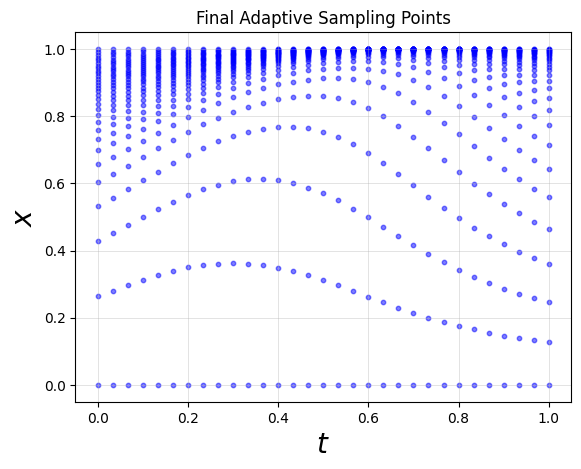

In [21]:
# 替换原来的训练cell
# 运行迭代训练
trained_model, final_collocation_pts = iterative_training_with_adaptive_sampling_kg(
    initial_epochs=pinn_initial_epochs,
    adaptive_epochs=pinn_adaptive_epochs,
    num_iterations=num_iterations,
    mmpde_training_epochs=mmpde_training_epochs
)

print("训练完成！")

# 可视化最终采样点
t_colloc_final = final_collocation_pts[:, 0:1]
x_colloc_final = final_collocation_pts[:, 1:2]

plt.scatter(t_colloc_final.detach().numpy(), x_colloc_final.detach().numpy(), 
           color='blue', alpha=0.5, s=10)
plt.xlabel('$t$', fontsize=20)
plt.ylabel('$x$', fontsize=20)
plt.title('Final Adaptive Sampling Points')
plt.grid(True, alpha=0.5, linestyle='-', linewidth=0.5)
plt.show()

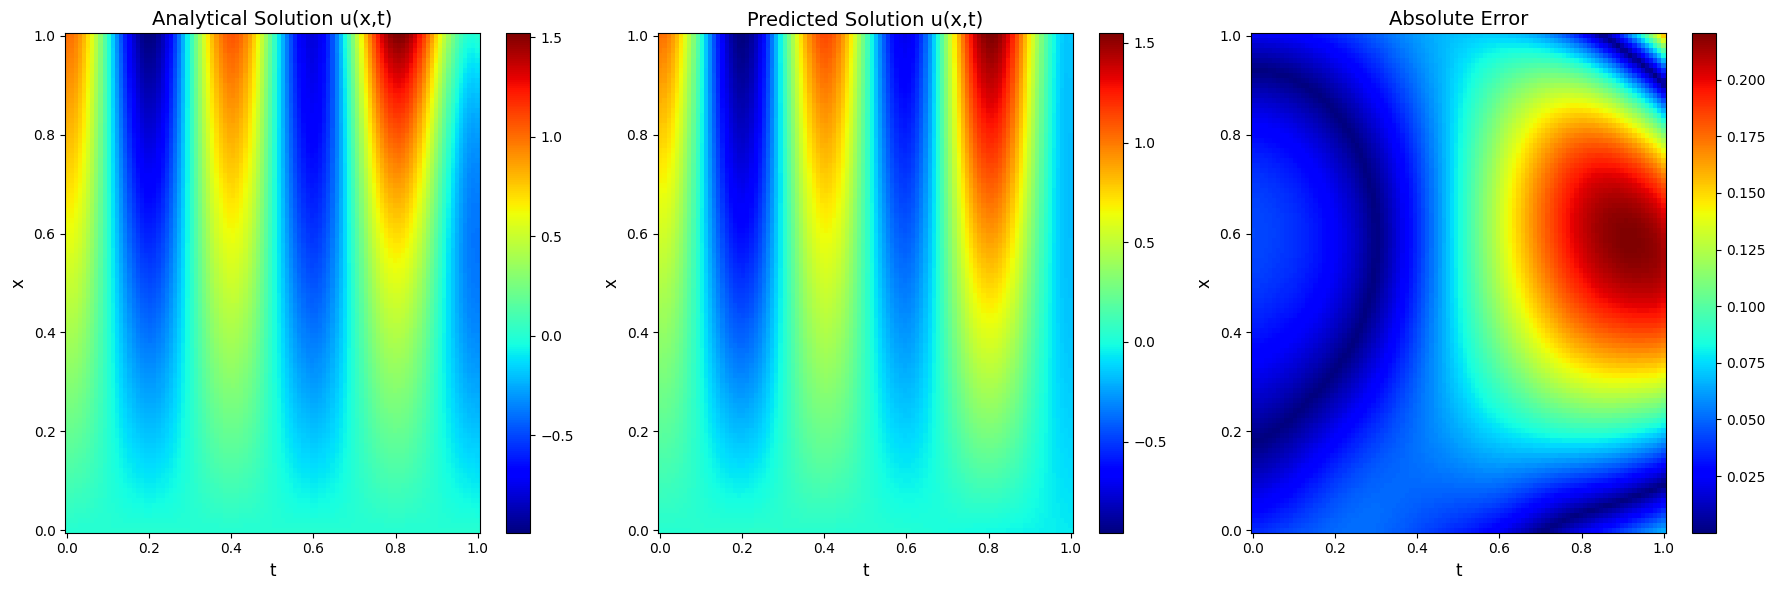

总体u的L2误差: 0.095973


In [22]:
nx, nt = 100, 100
x = torch.linspace(0, 1, nx).reshape(-1, 1)
t = torch.linspace(0, 1, nt).reshape(-1, 1)

X, T = torch.meshgrid(x.squeeze(), t.squeeze(), indexing='ij')

X_flat = X.reshape(-1, 1)
T_flat = T.reshape(-1, 1)

X_test = torch.cat([T_flat, X_flat], dim=1)

with torch.no_grad():
    u_pred = trained_model(X_test).reshape(nx, nt).detach().numpy()

u_exact = analytical_solution(T_flat, X_flat).reshape(nx, nt).detach().numpy()

u_error = np.abs(u_pred - u_exact)

plt.figure(figsize=(18, 6))

plt.subplot(131)
im = plt.pcolormesh(T.numpy(), X.numpy(), u_exact, cmap='jet', shading='auto')
plt.colorbar(im)
plt.xlabel('t', fontsize=12)
plt.ylabel('x', fontsize=12)
plt.title('Analytical Solution u(x,t)', fontsize=14)

plt.subplot(132)
im = plt.pcolormesh(T.numpy(), X.numpy(), u_pred, cmap='jet', shading='auto')
plt.colorbar(im)
plt.xlabel('t', fontsize=12)
plt.ylabel('x', fontsize=12)
plt.title('Predicted Solution u(x,t)', fontsize=14)

plt.subplot(133)
im = plt.pcolormesh(T.numpy(), X.numpy(), u_error, cmap='jet', shading='auto')
plt.colorbar(im)
plt.xlabel('t', fontsize=12)
plt.ylabel('x', fontsize=12)
plt.title('Absolute Error', fontsize=14)

plt.tight_layout()
plt.show()

total_u_l2_error = np.sqrt(np.mean(np.square(u_pred - u_exact)))
print(f"总体u的L2误差: {total_u_l2_error:.6f}")